# GG-PI: Sampling Example for Para-H₂

This notebook demonstrates how to apply GG-PI to sample para-H₂ at 25K with 32 beads using a pre-trained checkpoint.

**System:**
- Temperature: 25K
- Beads: 32
- Box: Periodic cubic box

In [1]:
# =============================================================================
# Import Dependencies
# =============================================================================
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle

# GG-PI package imports
from ggpi.nn import ViSNet_Velocity_Network
from ggpi.sampling import ConditionalFlowSampler, GibbsSampler

# Set paths
cwd = Path.cwd()
data_dir = cwd.parent / "data"
checkpoint_dir = cwd.parent / "checkpoints"

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# =============================================================================
# RDF Calculation Helper
# =============================================================================
import freud

def calculate_rdf(pos, box_size=None, r_range=(0.0, 14.0), nbins=50, stride=1):
    """
    Calculate radial distribution function using freud.
    
    Args:
        pos: Position array of shape (frames, atoms, 3) or (frames, beads, atoms, 3)
        box_size: Box dimensions [Lx, Ly, Lz]
        r_range: Range for RDF calculation
        nbins: Number of bins
        stride: Frame stride for efficiency
    
    Returns:
        Array of shape (nbins, 2) with [r, g(r)]
    """
    if pos.ndim == 4:
        pos = pos.reshape(-1, pos.shape[-2], pos.shape[-1])
    pos = np.asarray(pos, dtype=np.float32)[::stride]
    
    print(f"Calculating RDF for {pos.shape[0]} frames with {pos.shape[1]} atoms")
    
    if box_size is not None:
        box_size = np.asarray(box_size, dtype=np.float32)
        pos = pos - np.floor(pos / box_size) * box_size
    
    box = freud.box.Box(Lx=box_size[0], Ly=box_size[1], Lz=box_size[2])
    rdf = freud.density.RDF(bins=nbins, r_max=r_range[1], r_min=r_range[0])
    
    for i in range(pos.shape[0]):
        rdf.compute(system=(box, pos[i]), reset=False)
    
    return np.column_stack((rdf.bin_centers, rdf.rdf))

## Load Reference Data

MD data: (1001, 172, 3), box: [39.115 39.115 39.115]
Temperature: 100K, Units: atomic
PIMD data: (100, 32, 172, 3)
Calculating RDF for 1001 frames with 172 atoms
Calculating RDF for 3200 frames with 172 atoms


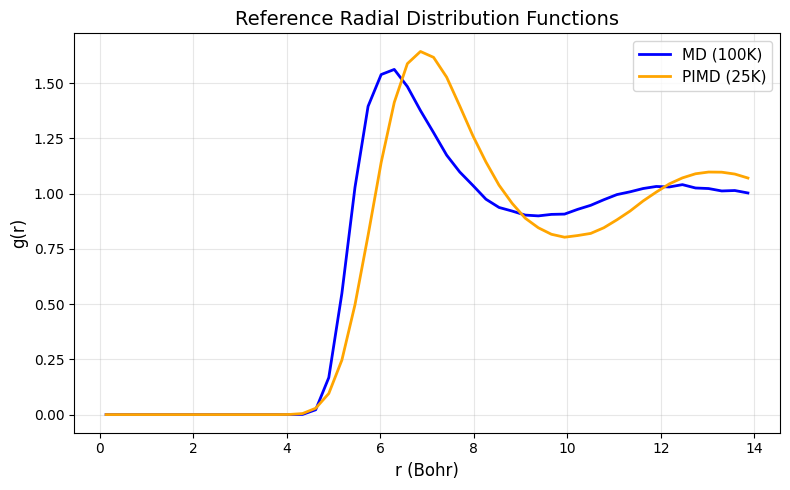

In [ ]:
# =============================================================================
# Load MD and PIMD Reference Data
# =============================================================================
# Load MD reference data
data_path = data_dir / "parah2_md_100K.pkl"
with open(data_path, "rb") as f:
    data = pickle.load(f)

pos = np.array(data["x"])
box_size = np.array(data["box_size"])
Z = np.array(data["Z"])
prior_sigma = np.array(data['prior_sigma'])

print(f"MD data: {pos.shape}, box: {box_size}")
print(f"Temperature: {data['T']}K, Units: {data['unit']}")

# Load PIMD reference data
pimd_path = data_dir / "parah2_pimd_25KP32.pkl"
with open(pimd_path, "rb") as f:
    pimd_data = np.array(pickle.load(f)['x'])
print(f"PIMD data: {pimd_data.shape}")

# Calculate reference RDFs
rdf_md = calculate_rdf(pos, box_size=box_size)
rdf_pimd = calculate_rdf(pimd_data, box_size=box_size)

# Plot reference comparison
plt.figure(figsize=(8, 5))
plt.plot(rdf_md[:, 0], rdf_md[:, 1], 'b-', linewidth=2, label='MD (100K)')
plt.plot(rdf_pimd[:, 0], rdf_pimd[:, 1], 'orange', linewidth=2, label='PIMD (25K)')
plt.xlabel('r (Bohr)', fontsize=12)
plt.ylabel('g(r)', fontsize=12)
plt.title('Reference Radial Distribution Functions', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Load Pre-trained Model

In [4]:
# =============================================================================
# Load Pre-trained Model and Setup Sampler
# =============================================================================
checkpoint_path = checkpoint_dir / "parah2.pt"

model = ViSNet_Velocity_Network.load_model(checkpoint_path, device=device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

# Compile model for faster inference (PyTorch >= 2.0)
model = torch.compile(model)

# Setup flow sampler
sampler = ConditionalFlowSampler(
    model,
    Z=torch.as_tensor(Z, dtype=torch.int64, device=device),
    prior_sigma=torch.as_tensor(prior_sigma, dtype=torch.float32, device=device),
    box_size=torch.as_tensor(box_size, dtype=torch.float32, device=device),
    device=device,
    sample_method='heun',
    fix_graph=True,
    num_steps=3,
    max_batch_size=2048,
    return_cpu=False
)

# Setup Gibbs sampler
gibbs = GibbsSampler(
    sampler,
    box_size=torch.as_tensor(box_size, dtype=torch.float32, device=device),
    device=device
)

Model parameters: 35,016
ConditionalFlowSampler initialized: method=heun, steps=3, fix_graph=True
GibbsSampler initialized on cuda, cutoff=10.0, cache_interval=5, cache_threshold=2.0, use_cache=True


## Run GG-PI Sampling

In [5]:
# =============================================================================
# Run Gibbs Sampling
# =============================================================================
import time

torch.cuda.empty_cache()

# Select random initial configurations from MD data
num_initial = 20
random_indices = np.random.choice(pos.shape[0], num_initial, replace=False)
initial_configs = pos[random_indices]
initial_configs = torch.as_tensor(initial_configs, dtype=torch.float32, device=device)

print(f"Initial configurations: {initial_configs.shape}")

# Run Gibbs sampling
start = time.time()
output, history = gibbs.sample(
    initial_configs,
    num_beads=32,
    max_iterations=800,
    record_freq=100
)
print(f"Gibbs sampling completed in {time.time() - start:.2f} seconds")

Initial configurations: torch.Size([20, 172, 3])
Initial Rg: 5.938124991722304e-10, num_beads: 32
Step: 100/800, Rg: 0.723913311958313
Step: 200/800, Rg: 0.726918637752533
Step: 300/800, Rg: 0.7204161882400513
Step: 400/800, Rg: 0.7362462282180786
Step: 500/800, Rg: 0.7266385555267334
Step: 600/800, Rg: 0.7319708466529846
Step: 700/800, Rg: 0.7304374575614929
Step: 800/800, Rg: 0.7350485920906067
Gibbs sampling completed in 80.47 seconds


## Compare Results

Calculating RDF for 640 frames with 172 atoms
Calculating RDF for 20 frames with 172 atoms


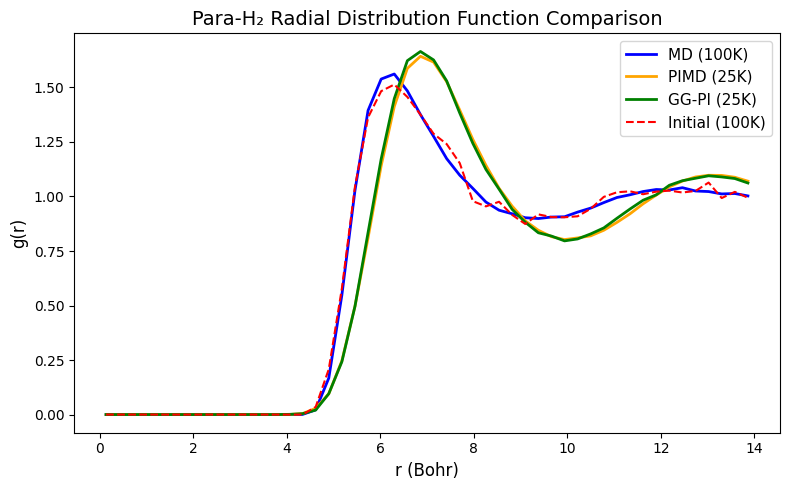

In [7]:
# =============================================================================
# Compare RDF Results
# =============================================================================
rdf_ggpi = calculate_rdf(output, box_size=box_size)
rdf_init = calculate_rdf(initial_configs.cpu().numpy(), box_size=box_size)

plt.figure(figsize=(8, 5))
plt.plot(rdf_md[:, 0], rdf_md[:, 1], 'b-', linewidth=2, label='MD (100K)')
plt.plot(rdf_pimd[:, 0], rdf_pimd[:, 1], 'orange', linewidth=2, label='PIMD (25K)')
plt.plot(rdf_ggpi[:, 0], rdf_ggpi[:, 1], 'g-', linewidth=2, label='GG-PI (25K)')
plt.plot(rdf_init[:, 0], rdf_init[:, 1], 'r--', linewidth=1.5, label='Initial (100K)')

plt.xlabel('r (Bohr)', fontsize=12)
plt.ylabel('g(r)', fontsize=12)
plt.title('Para-H₂ Radial Distribution Function Comparison', fontsize=14)
plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()